In [1]:
netlist = """\
Buck Converter CCM
Vin in 0 DC $VIN
Vpwm gate 0 PULSE(0 5 0 1n 1n $TON $T)
S1 in sw gate 0 SWMOD
D1 0 sw DMOD
L1 sw out $L IC=0
C1 out 0 $C IC=0
RL out 0 $R

.MODEL SWMOD SW(Ron=0.01 Roff=1MEG Vt=2.5)
.MODEL DMOD D(Is=1n N=1 Rs=0.01)

.SAVE v(out) v(sw) i(L1)

.TRAN $TSTEP $TEND $TSTART UIC
.END
"""

with open('buck_orig.cir', 'w') as f:
    f.write(netlist)

print("buck_orig.cir written")

buck_orig.cir written


In [2]:
import numpy as np
import ngspice_calc as calc
import matplotlib.pyplot as plt

Vin = 100.0
Vout = 25.0
R = 2.5
fs = 10e3
T = 1/fs
D = Vout/Vin
Iout = Vout/R
dIL_ratio = 0.20
dVc = 0.1
dIL = dIL_ratio * Iout
L = (Vin - Vout)*D / (fs * dIL)
C = dIL / (8 * fs * dVc)
IL_peak = Iout + dIL/2
IL_min  = Iout - dIL/2
Ton   = D * T
Tstep = T / 200
Tend  = 100 * T
Tstart = 35 * T    

print(f'D = {D:.4f}')
print(f'Iout = {Iout:.4f} A')
print(f'dIL = {dIL:.4f} A')
print(f'IL_peak = {IL_peak:.4f} A')
print(f'IL_min = {IL_min:.4f} A')
print(f'L = {L*1e3:.4f} mH')
print(f'C = {C*1e6:.4f} uF')
print(f'T = {T*1e6:.2f} us')
print(f'Ton = {Ton*1e6:.2f} us')
print(f'Tstart = {Tstart*1e3:.2f} ms  (raw file starts here)')
print(f'Tend = {Tend*1e3:.2f} ms')

D = 0.2500
Iout = 10.0000 A
dIL = 2.0000 A
IL_peak = 11.0000 A
IL_min = 9.0000 A
L = 0.9375 mH
C = 250.0000 uF
T = 100.00 us
Ton = 25.00 us
Tstart = 3.50 ms  (raw file starts here)
Tend = 10.00 ms


In [3]:
l = [
    ('$VIN',    f'{Vin}'),
    ('$TON',    f'{Ton:.10f}'),
    ('$T',      f'{T:.10f}'),
    ('$L',      f'{L:.2e}'),
    ('$C',      f'{C:.2e}'),
    ('$R',      f'{R}'),
    ('$TSTEP',  f'{Tstep:.10f}'),
    ('$TEND',   f'{Tend:.8f}'),
    ('$TSTART', f'{Tstart:.8f}'),
]

calc.replace_strings_1('buck_orig.cir', 'buck.cir', l)
calc.run_ngspice('buck.cir')


Note: No compatibility mode selected!


Circuit: buck converter ccm

binary raw file "buck.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 4  
Operating point simulation skipped by 'uic',
  now using transient initial conditions.

No. of Data Rows : 16289

Total analysis time (seconds) = 0.093366

Total elapsed time (seconds) = 0.095 

Total DRAM available = 15614.742 MB.
DRAM currently available = 3339.863 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.660 MB.

Shared ngspice pages =   10.879 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'buck.raw'

In [4]:
s = calc.slv('buck.cir')

for i in range(s.num_plots()):
    print(f"  plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

  plot 0: Transient Analysis | type: tran | vars: ['time', 'v(out)', 'v(sw)', 'i(l1)']


In [5]:
t = s.get_array('time')
v_out = s.get_array('v(out)')
v_sw = s.get_array('v(sw)')
i_L1 = s.get_array('i(l1)')

print(f'Time range: {t[0]*1e3:.4f} ms to {t[-1]*1e3:.4f} ms')

Time range: 3.5000 ms to 10.0000 ms


In [6]:
mask = t >= t[-1] - 2 * T
t_ss = t[mask]
Vout_ss = v_out[mask]
IL_ss = i_L1[mask]


t0 = t[0]
t1 = t[-1]

v_avg, v_rms = calc.avg_rms(t, v_out, t0, t1)
v_min, v_max = calc.min_max(t, v_out, t0, t1)
i_avg, i_rms = calc.avg_rms(t, i_L1, t0, t1)
i_min, i_max = calc.min_max(t, i_L1, t0, t1)

print(f'Vout avg (steady state) = {v_avg:.4f} V  (target: {Vout} V)')
print(f'IL avg (steady state) = {i_avg:.4f} A  (target: {Iout:.4f} A)')
print(f'IL rms (steady state) = {i_rms:.4f} A')

Vout avg (steady state) = 24.4202 V  (target: 25.0 V)
IL avg (steady state) = 9.8266 A  (target: 10.0000 A)
IL rms (steady state) = 9.8447 A


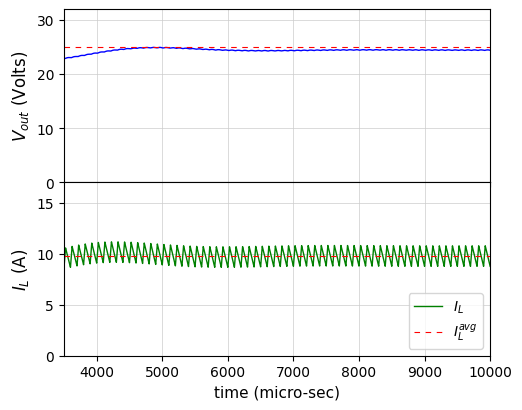

In [7]:
import matplotlib.pyplot as plt

color1 = 'blue'
color2 = 'green'
color3 = 'red'

fig, ax = plt.subplots(2, sharex=False, figsize=(5.5, 4.5))
plt.subplots_adjust(wspace=0, hspace=0.0)

for i in range(2):
    ax[i].set_xlim(left=t0 * 1e6, right=t1 * 1e6)
    ax[i].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

ax[0].set_ylim(0, 32)
ax[1].set_ylim(0, 17)

ax[0].set_ylabel(r'$V_{out}$ (Volts)', fontsize=12)
ax[1].set_ylabel(r'$I_L$ (A)', fontsize=12)
ax[0].tick_params(labelbottom=False)

ax[0].plot(t * 1e6, v_out, color=color1, linewidth=1.0, label=r'$V_{out}$')
ax[1].plot(t * 1e6, i_L1,   color=color2, linewidth=1.0, label=r'$I_L$')

ax[0].axhline(y=Vout,  color=color3, linestyle='--', linewidth=0.8, dashes=(5, 5))
ax[1].axhline(y=i_avg, color=color3, linestyle='--', linewidth=0.8, dashes=(5, 5), label=r'$I_L^{avg}$')

ax[1].set_xlabel('time (micro-sec)', fontsize=11)
ax[1].legend(loc='lower right', fontsize=10)

plt.show()